# Route 208 — Battery Electric Bus Energy & Loading Analysis

Segment → trip → duty energy consumption and passenger-loading analysis for the
simulated BEB operation of route **208 (Lotabeg - Bishopstown - Curraheen)**.

The data is one simulated service day (`2025-01-06`) covering two service variants,
16 vehicle blocks, 32 duties, 412 trips and ~15.1k stop-to-stop segments. The
pipeline writes per-segment energy (`net_battery_energy_kWh`), specific consumption
(`net_battery_kWh_per_km`), grade, passenger load and a continuous state-of-charge that carries
across trips within a duty.

**Structure**
1. Setup, load, derived fields
2. Data overview & sanity checks (incl. implied pack capacity)
3. Segment-level energy analysis
4. Trip-level energy analysis
5. Duty-level energy & SoC-trajectory analysis
6. Passenger-loading analysis
7. Synthesis

## 1 · Setup, load & derived fields

In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# ----- a cohesive visual theme used across every figure -----------------------
INK   = "#1f2433"   # text / spines
OUT   = "#2a9d8f"   # direction 0  (outbound)
IN    = "#e76f51"   # direction 1  (inbound)
ACC   = "#3d5a80"   # single-series primary
ACC2  = "#ee9b00"   # secondary accent
REGEN = "#52b788"   # regeneration
GRID  = "#dde1e7"
DIRCOLORS = {0: OUT, 1: IN}
SEQ = "mako"        # sequential colormap for heatmaps

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})

def titled(ax, title, subtitle=None):
    """Bold title with an optional muted subtitle line beneath it."""
    ax.set_title(title, loc="left", pad=24 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9.5, color="#6b7280", ha="left", va="bottom")
    return ax

# --- energy-schema handling --------------------------------------------------
# The model now writes an explicit energy breakdown and no longer emits the
# ambiguous energy_kWh / kWh_per_km. Canonical columns used throughout:
#   net_battery_energy_kWh   = gross_consumed + aux_energy - regen_recovered
#                              (the SoC-changing quantity; was energy_kWh)
#   net_battery_kWh_per_km   = net per km   (was kWh_per_km)
#   gross_consumed_kWh / regen_recovered_kWh / aux_energy_kWh   (new breakdown)
#   gross_consumed_kWh_per_km                                   (new)
BREAKDOWN_COLS = ["gross_consumed_kWh", "regen_recovered_kWh", "aux_energy_kWh"]

def normalize_energy_schema(d):
    """Accept the new explicit schema or a legacy energy_kWh/kWh_per_km file,
    returning a frame that always carries the canonical net_battery_* columns.
    Legacy energy_kWh was already net battery energy, so it maps straight over;
    the gross/regen/aux breakdown simply isn't available for legacy files."""
    d = d.copy()
    if "net_battery_energy_kWh" not in d and "energy_kWh" in d:
        d["net_battery_energy_kWh"] = d["energy_kWh"]
    if "net_battery_kWh_per_km" not in d and "kWh_per_km" in d:
        d["net_battery_kWh_per_km"] = d["kWh_per_km"]
    return d

def has_breakdown(d):
    return set(BREAKDOWN_COLS).issubset(d.columns)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [338]:
# Single-day deep dive runs on PRIMARY_CSV (the multi-date comparison is §8).
PRIMARY_CSV = "../data/processed/route_208_trips_2025_04_14.csv"
df = normalize_energy_schema(pd.read_csv(PRIMARY_CSV))
HAS_BREAKDOWN = has_breakdown(df)   # gross/regen/aux available?

# --- derived fields ----------------------------------------------------------
df["dist_km"]   = df["length_m"] / 1000.0
df["speed_kmh"] = df["length_m"] / df["run_time_s"] * 3.6        # in-motion avg speed
df["is_regen"]  = df["net_battery_energy_kWh"] < 0
df["dir_label"] = df["direction_id"].map({0: "Outbound", 1: "Inbound"})

# clock / time-of-day from each trip's scheduled departure
df["dep_dt"]   = pd.to_datetime(df["trip_start_time"], format="%H:%M:%S")
df["dep_hour"] = df["dep_dt"].dt.hour

def tod(h):
    if h < 7:   return "Early (<07)"
    if h <= 9:  return "AM peak (07-09)"
    if h <= 15: return "Midday (10-15)"
    if h <= 18: return "PM peak (16-18)"
    return "Evening (19+)"
TOD_ORDER = ["Early (<07)", "AM peak (07-09)", "Midday (10-15)",
             "PM peak (16-18)", "Evening (19+)"]
df["period"] = pd.Categorical(df["dep_hour"].map(tod), TOD_ORDER, ordered=True)

# a real timeline for SoC plots. GTFS times can exceed 24:00:00 for post-midnight
# service, so parse as seconds-since-midnight offsets from the simulated date.
def gtfs_seconds(s):
    parts = s.str.split(":", expand=True).astype(int)
    return parts[0] * 3600 + parts[1] * 60 + parts[2]
df["seg_arr_dt"] = (pd.to_datetime(df["simulation_date"])
                    + pd.to_timedelta(gtfs_seconds(df["to_stop_arrival_time"]), unit="s"))

print(f"{len(df):,} segments | {df.trip_id.nunique()} trips | "
      f"{df.duty_id.nunique()} duties | {df.block_id.nunique()} blocks")
print("energy breakdown (gross/regen/aux):",
      "available" if HAS_BREAKDOWN else "NOT in this file — legacy schema, "
      "breakdown sections will be skipped")
df.head(3)

7,561 segments | 206 trips | 16 duties | 16 blocks
energy breakdown (gross/regen/aux): available


,route_short_name,route_long_name,route_id,service_id,block_id,duty_id,duty_index,duty_trip_index,duty_trip_count,duty_start_time,direction_id,trip_id,simulation_date,trip_start_time,trip_start_soc_%,segment,from_stop_departure_time,to_stop_arrival_time,to_stop_departure_time,run_time_s,...,grade_%,passengers,net_battery_energy_kWh,gross_consumed_kWh,regen_recovered_kWh,aux_energy_kWh,net_battery_kWh_per_km,gross_consumed_kWh_per_km,cum_dist_km,SoC_start_%,SoC_end_%,trip_end_soc_%,dist_km,speed_kmh,is_regen,dir_label,dep_dt,dep_hour,period,seg_arr_dt
0,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,228,5695_7778208_42080203,228:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40635,2025-04-14,06:30:00,100.0,0,06:30:00,06:31:00,06:31:00,60,...,-0.46,0,0.118,0.078,0.011,0.050,0.536,0.356,0.219,100.00,99.97,97.48,0.2193,13.1580,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-04-14 06:31:00
1,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,228,5695_7778208_42080203,228:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40635,2025-04-14,06:30:00,100.0,1,06:31:00,06:33:30,06:33:30,150,...,-0.56,0,0.230,0.115,0.011,0.125,0.430,0.216,0.753,99.97,99.92,97.48,0.5341,12.8184,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-04-14 06:33:30
2,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,228,5695_7778208_42080203,228:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40635,2025-04-14,06:30:00,100.0,2,06:33:30,06:34:30,06:34:30,60,...,-0.25,2,0.266,0.267,0.050,0.050,0.669,0.670,1.152,99.92,99.85,97.48,0.3982,23.8920,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-04-14 06:34:30


## 2 · Data overview & sanity checks

Before analysis, confirm the hierarchy and back out the battery pack capacity the
simulator implied (energy drawn per percent of SoC consumed). A tight spread here
is a good integrity check on the SoC bookkeeping.

In [339]:
# derive pack capacity per duty: total energy / total SoC drop across its trips
cap_rows = []
for did, g in df.groupby("duty_id"):
    tr = g.groupby("duty_trip_index").agg(e=("net_battery_energy_kWh", "sum"),
                                          s0=("trip_start_soc_%", "first"),
                                          s1=("trip_end_soc_%", "first"))
    drop = (tr.s0 - tr.s1).sum()
    if drop > 0:
        cap_rows.append(tr.e.sum() / (drop / 100.0))
cap = np.array(cap_rows)
BATTERY_KWH = float(np.median(cap))

overview = pd.Series({
    "Route":                  f"208 — {df.route_long_name.iloc[0]}",
    "Simulated date":         df.simulation_date.iloc[0],
    "Service variants":       ", ".join(map(str, sorted(df.service_id.unique()))),
    "Blocks / duties / trips": f"{df.block_id.nunique()} / {df.duty_id.nunique()} / {df.trip_id.nunique()}",
    "Segments":               f"{len(df):,}",
    "Total distance (km)":    f"{df.dist_km.sum():,.0f}",
    "Net battery energy (kWh)": f"{df.net_battery_energy_kWh.sum():,.0f}",
    "Fleet mean (kWh/km)":    f"{df.net_battery_energy_kWh.sum()/df.dist_km.sum():.3f}",
    "Regen segments":         f"{df.is_regen.mean()*100:.1f}%",
    "Implied pack (kWh)":     f"{BATTERY_KWH:.0f}  (spread {cap.min():.1f}-{cap.max():.1f})",
}, name="value")
if HAS_BREAKDOWN:
    net, gross = df.net_battery_energy_kWh.sum(), df.gross_consumed_kWh.sum()
    regen, aux = df.regen_recovered_kWh.sum(), df.aux_energy_kWh.sum()
    overview["Gross traction (kWh)"] = f"{gross:,.0f}  ({gross/net*100:.0f}% of net)"
    overview["Auxiliary/HVAC (kWh)"] = f"{aux:,.0f}  ({aux/net*100:.0f}% of net)"
    overview["Regen recovered (kWh)"] = f"{regen:,.0f}  ({regen/gross*100:.0f}% of gross)"
print(overview.to_string())

Route                       208 — Lotabeg - Bishopstown - Curraheen
Simulated date                                           2025-04-14
Service variants                                                228
Blocks / duties / trips                               16 / 16 / 206
Segments                                                      7,561
Total distance (km)                                           2,463
Net battery energy (kWh)                                      3,797
Fleet mean (kWh/km)                                           1.541
Regen segments                                                13.7%
Implied pack (kWh)                        410  (spread 409.8-410.2)
Gross traction (kWh)                           4,349  (115% of net)
Auxiliary/HVAC (kWh)                              480  (13% of net)
Regen recovered (kWh)                         1,033  (24% of gross)


In [340]:
# missing-value & range check
chk = pd.DataFrame({
    "nulls": df.isna().sum(),
}).query("nulls > 0")
print("Columns with nulls:", "none" if chk.empty else "")
if not chk.empty:
    print(chk)

num = ["run_time_s","dwell_s","dist_km","speed_kmh","grade_%","passengers",
       "net_battery_energy_kWh","net_battery_kWh_per_km"]
df[num].describe().T[["mean","std","min","25%","50%","75%","max"]].round(3)

Columns with nulls: none


,mean,std,min,25%,50%,75%,max
run_time_s,67.662,51.633,30.000,30.000,60.000,60.000,300.000
dwell_s,8.558,55.371,0.000,0.000,0.000,0.000,570.000
dist_km,0.326,0.131,0.148,0.235,0.285,0.390,0.772
speed_kmh,22.091,10.549,2.253,14.152,19.641,28.200,54.144
grade_%,-0.187,3.029,-7.690,-1.680,0.000,1.250,6.310
passengers,31.144,23.890,0.000,9.000,29.000,51.000,85.000
net_battery_energy_kWh,0.502,0.519,-0.236,0.150,0.355,0.748,2.756
net_battery_kWh_per_km,1.530,1.491,-0.939,0.617,1.140,2.426,6.534


## 3 · Segment-level energy analysis

The stop-to-stop segment is the model's atomic unit. We look at the distribution of
per-segment net battery energy and specific consumption, the prevalence of regeneration,
and the three physical drivers the quasi-static model is sensitive to: **grade, speed and
passenger mass**.

The refactored model now writes the explicit energy balance per segment —
`net = gross_consumed + aux_energy − regen_recovered` — so where those columns are
present we decompose consumption directly instead of inferring it.

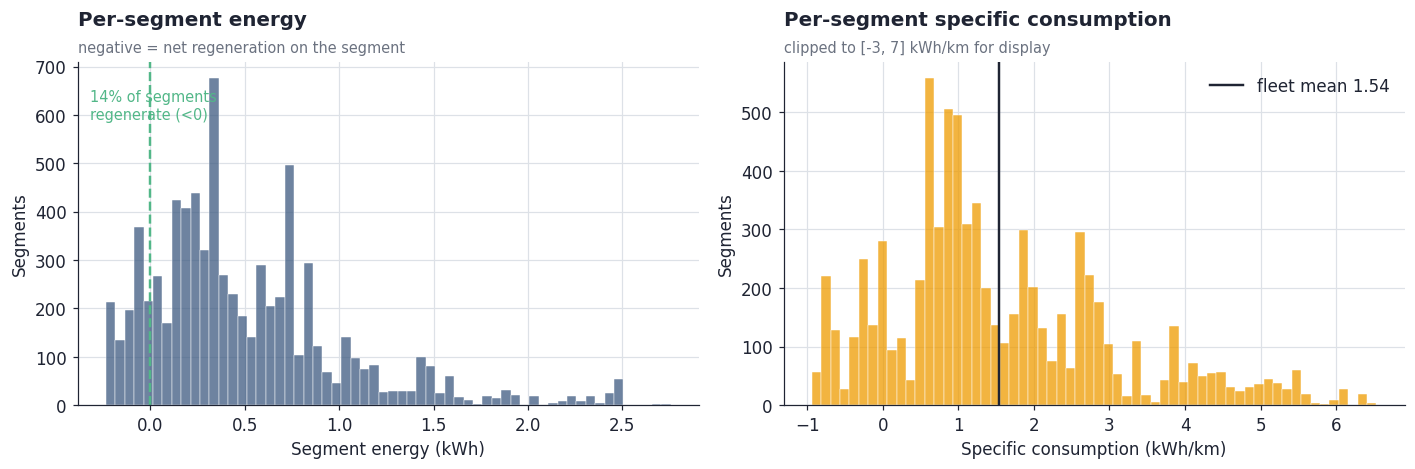

In [341]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
sns.histplot(df.net_battery_energy_kWh, bins=60, color=ACC, edgecolor="white", linewidth=.3, ax=ax)
ax.axvline(0, color=REGEN, lw=1.6, ls="--")
ax.text(0.02, 0.92, f"{df.is_regen.mean()*100:.0f}% of segments\nregenerate (<0)",
        transform=ax.transAxes, color=REGEN, fontsize=9.5, va="top")
ax.set_xlabel("Segment energy (kWh)"); ax.set_ylabel("Segments")
titled(ax, "Per-segment energy", "negative = net regeneration on the segment")

ax = axes[1]
m = df.net_battery_kWh_per_km.between(-3, 7)
sns.histplot(df.loc[m, "net_battery_kWh_per_km"], bins=60, color=ACC2, edgecolor="white",
             linewidth=.3, ax=ax)
ax.axvline(df.net_battery_energy_kWh.sum()/df.dist_km.sum(), color=INK, lw=1.6,
           label=f"fleet mean {df.net_battery_energy_kWh.sum()/df.dist_km.sum():.2f}")
ax.set_xlabel("Specific consumption (kWh/km)"); ax.set_ylabel("Segments")
ax.legend(loc="upper right")
titled(ax, "Per-segment specific consumption", "clipped to [-3, 7] kWh/km for display")
plt.tight_layout(); plt.show()

### Energy balance: traction vs auxiliary vs regen

With the explicit breakdown we can split net battery draw into its physical parts.
Auxiliary/HVAC is *time*-based, so its per-km share falls as the bus goes faster — a
signature that cleanly separates it from traction. *(Skipped automatically on legacy
files without the breakdown columns.)*

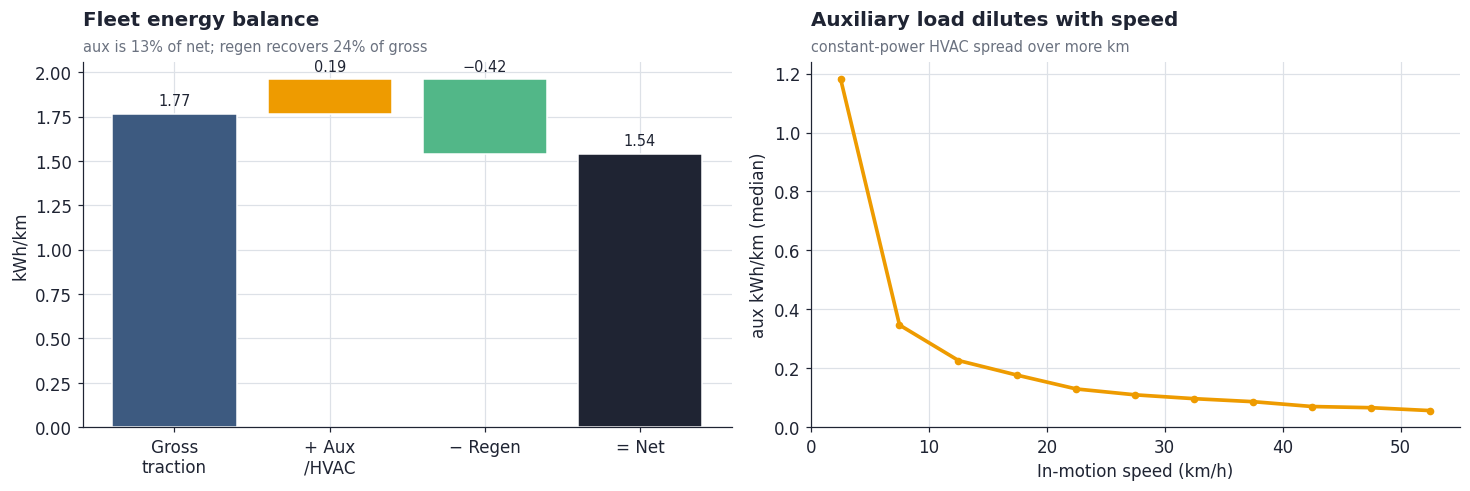

In [342]:
if not HAS_BREAKDOWN:
    print("Energy breakdown columns not present in this file — skipping. "
          "Re-run once the CSV carries gross_consumed_kWh / regen_recovered_kWh / "
          "aux_energy_kWh.")
else:
    tot_km = df.dist_km.sum()
    gpk = df.gross_consumed_kWh.sum() / tot_km
    apk = df.aux_energy_kWh.sum()    / tot_km
    rpk = df.regen_recovered_kWh.sum() / tot_km
    npk = df.net_battery_energy_kWh.sum() / tot_km

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

    # ── waterfall: how the parts add up to net kWh/km ──
    ax = axes[0]
    labels = ["Gross\ntraction", "+ Aux\n/HVAC", "− Regen", "= Net"]
    ax.bar(0, gpk, color=ACC, edgecolor="white")
    ax.bar(1, apk, bottom=gpk, color=ACC2, edgecolor="white")
    ax.bar(2, rpk, bottom=gpk + apk - rpk, color=REGEN, edgecolor="white")
    ax.bar(3, npk, color=INK, edgecolor="white")
    for xi, (lab, val, top) in enumerate(zip(labels,
            [gpk, apk, rpk, npk], [gpk, gpk+apk, gpk+apk, npk])):
        sign = "−" if lab.startswith("− ") else ""
        ax.text(xi, top + .03, f"{sign}{val:.2f}", ha="center", va="bottom", fontsize=9.5)
    ax.set_xticks(range(4)); ax.set_xticklabels(labels)
    ax.set_ylabel("kWh/km")
    titled(ax, "Fleet energy balance",
           f"aux is {apk/npk*100:.0f}% of net; regen recovers "
           f"{rpk/gpk*100:.0f}% of gross")

    # ── aux specific energy falls with speed (time-based load) ──
    ax = axes[1]
    d2 = df[df.speed_kmh.between(2, 60)].copy()
    d2["aux_per_km"] = d2.aux_energy_kWh / d2.dist_km
    d2["spd_bin"] = pd.cut(d2.speed_kmh, np.arange(0, 60, 5))
    s = d2.groupby("spd_bin", observed=True)["aux_per_km"].median()
    ax.plot([iv.mid for iv in s.index], s.values, color=ACC2, lw=2.4, marker="o", ms=4)
    ax.set_xlabel("In-motion speed (km/h)"); ax.set_ylabel("aux kWh/km (median)")
    titled(ax, "Auxiliary load dilutes with speed",
           "constant-power HVAC spread over more km")
    plt.tight_layout(); plt.show()

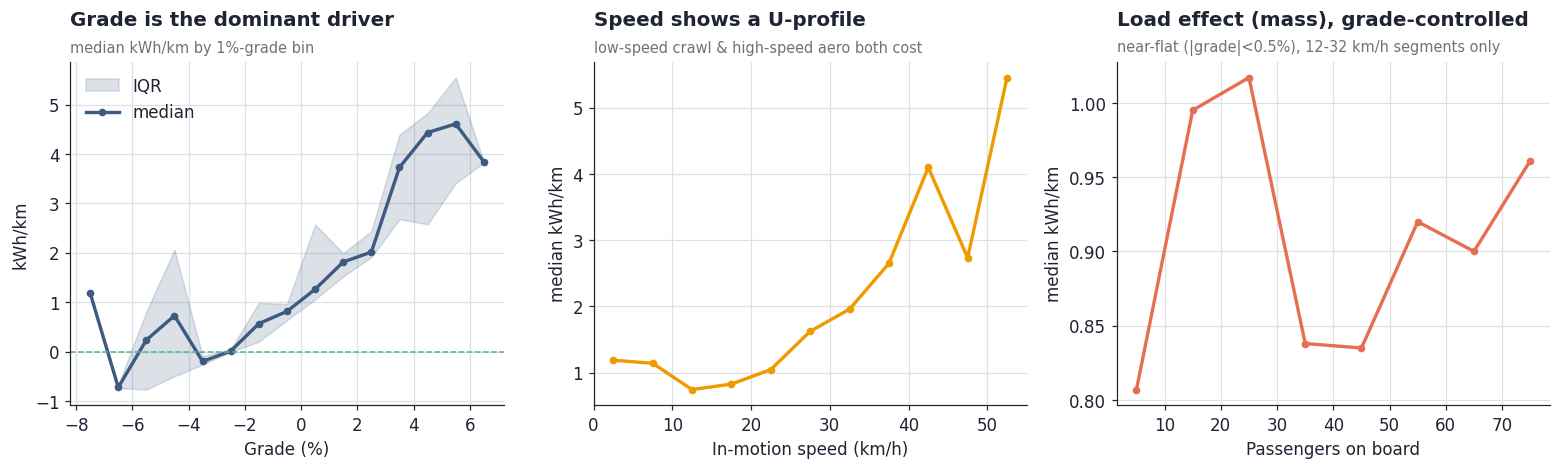

In [343]:
# Driver 1 — grade. Bin grade and show median kWh/km with IQR band.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharey=False)

d = df[df.net_battery_kWh_per_km.between(-4, 8)].copy()
d["grade_bin"] = pd.cut(d["grade_%"], np.arange(-9, 9, 1))
gb = d.groupby("grade_bin", observed=True)["net_battery_kWh_per_km"].agg(["median","count",
        lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
gb.columns = ["median","n","q1","q3"]
x = [iv.mid for iv in gb.index]
ax = axes[0]
ax.fill_between(x, gb.q1, gb.q3, color=ACC, alpha=.18, label="IQR")
ax.plot(x, gb["median"], color=ACC, lw=2.2, marker="o", ms=4, label="median")
ax.axhline(0, color=REGEN, lw=1, ls="--")
ax.set_xlabel("Grade (%)"); ax.set_ylabel("kWh/km")
ax.legend(loc="upper left")
titled(ax, "Grade is the dominant driver", "median kWh/km by 1%-grade bin")

# Driver 2 — speed (U-shape: idle/HVAC at low speed, aero at high speed)
d["spd_bin"] = pd.cut(d["speed_kmh"], np.arange(0, 60, 5))
sb = d.groupby("spd_bin", observed=True)["net_battery_kWh_per_km"].median()
ax = axes[1]
ax.plot([iv.mid for iv in sb.index], sb.values, color=ACC2, lw=2.2, marker="o", ms=4)
ax.set_xlabel("In-motion speed (km/h)"); ax.set_ylabel("median kWh/km")
titled(ax, "Speed shows a U-profile", "low-speed crawl & high-speed aero both cost")

# Driver 3 — passenger load (mass), on near-flat segments to isolate it
flat = d[(d["grade_%"].abs() < 0.5) & d["speed_kmh"].between(12, 32)].copy()
flat["pax_bin"] = pd.cut(flat["passengers"], np.arange(0, 90, 10))
pb = flat.groupby("pax_bin", observed=True)["net_battery_kWh_per_km"].median()
ax = axes[2]
ax.plot([iv.mid for iv in pb.index], pb.values, color=IN, lw=2.2, marker="o", ms=4)
ax.set_xlabel("Passengers on board"); ax.set_ylabel("median kWh/km")
titled(ax, "Load effect (mass), grade-controlled",
       "near-flat (|grade|<0.5%), 12-32 km/h segments only")
plt.tight_layout(); plt.show()

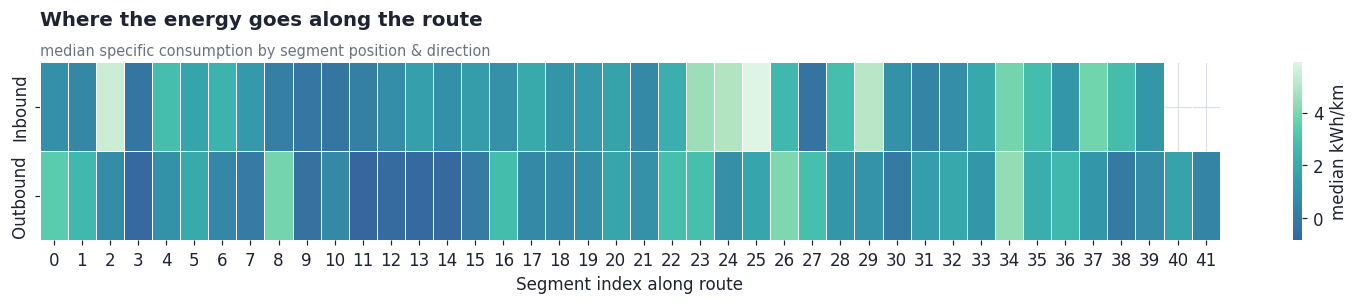

In [344]:
# Energy intensity along the route — segment position x direction
heat = (df.pivot_table(index="dir_label", columns="segment",
                       values="net_battery_kWh_per_km", aggfunc="median"))
fig, ax = plt.subplots(figsize=(14, 2.9))
sns.heatmap(heat, cmap=SEQ, center=0, linewidths=.4, linecolor="white",
            cbar_kws={"label": "median kWh/km"}, ax=ax)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("")
titled(ax, "Where the energy goes along the route",
       "median specific consumption by segment position & direction")
plt.tight_layout(); plt.show()

In [345]:
# Descriptive least-squares decomposition of segment net energy.
# net ≈ β0 + β1·dist + β2·(grade·dist) + β3·(pax·dist) + β4·(dist/speed)
# Kept as a cross-check: where the breakdown columns exist, the β4 (dist/speed)
# term is now measured directly by aux_energy_kWh, so treat this as bookkeeping
# that should roughly reconcile with the explicit aux above — not a causal model.
sub = df[(df.run_time_s > 0) & df.speed_kmh.between(2, 60)].copy()
X = pd.DataFrame({
    "intercept":  1.0,
    "dist_km":    sub.dist_km,
    "grade·dist": sub["grade_%"] * sub.dist_km,
    "pax·dist":   sub.passengers * sub.dist_km,
    "time(dist/spd)": sub.dist_km / sub.speed_kmh,
})
y = sub.net_battery_energy_kWh.values
beta, *_ = np.linalg.lstsq(X.values, y, rcond=None)
yhat = X.values @ beta
ss_res = ((y - yhat) ** 2).sum(); ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

coef = pd.Series(beta, index=X.columns).round(4)
print("Descriptive decomposition of segment energy (kWh)")
print("-" * 48)
print(coef.to_string())
print("-" * 48)
print(f"R² = {r2:.3f}   n = {len(sub):,}")
print("\nReading: ~", round(coef['dist_km'],2), "kWh/km baseline rolling+aux;",
      "+", round(coef['grade·dist'],3), "kWh per km per +1% grade;",
      "+", round(coef['pax·dist']*10,3), "kWh per km per +10 pax.")

Descriptive decomposition of segment energy (kWh)
------------------------------------------------
intercept         0.2682
dist_km           1.3156
grade·dist        0.3969
pax·dist         -0.0042
time(dist/spd)   -8.1554
------------------------------------------------
R² = 0.641   n = 7,561

Reading: ~ 1.32 kWh/km baseline rolling+aux; + 0.397 kWh per km per +1% grade; + -0.042 kWh per km per +10 pax.


## 4 · Trip-level energy analysis

Rolling segments up to whole trips (one end-to-end run). We compare directions —
which differ in net grade — and trace the time-of-day signature that passenger
loading imprints on consumption.

In [346]:
trips = (df.groupby("trip_id")
    .agg(duty_id=("duty_id","first"), direction=("direction_id","first"),
         dir_label=("dir_label","first"), period=("period","first"),
         dep_hour=("dep_hour","first"), dep_time=("trip_start_time","first"),
         segs=("segment","count"), dist_km=("dist_km","sum"),
         dur_min=("run_time_s", lambda s: (s.sum()+0)/60),
         net_battery_energy_kWh=("net_battery_energy_kWh","sum"), pax_mean=("passengers","mean"),
         pax_max=("passengers","max"),
         soc0=("trip_start_soc_%","first"), soc1=("trip_end_soc_%","first"))
    .reset_index())
trips["net_battery_kWh_per_km"] = trips.net_battery_energy_kWh / trips.dist_km
trips["soc_drop"]   = trips.soc0 - trips.soc1
trips["dur_min"]    = (df.groupby("trip_id")["run_time_s"].sum()
                       + df.groupby("trip_id")["dwell_s"].sum()).values / 60
print(f"{len(trips)} trips")
trips[["dist_km","dur_min","net_battery_energy_kWh","net_battery_kWh_per_km","pax_mean","soc_drop"]]     .describe().loc[["mean","std","min","50%","max"]].round(2)

206 trips


,dist_km,dur_min,net_battery_energy_kWh,net_battery_kWh_per_km,pax_mean,soc_drop
mean,11.96,46.63,18.43,1.53,30.58,4.50
std,1.47,8.42,4.38,0.29,11.50,1.07
min,5.00,13.00,4.13,0.83,0.00,1.01
50%,12.28,48.50,17.12,1.46,32.14,4.18
max,14.18,60.50,24.85,2.00,47.28,6.06


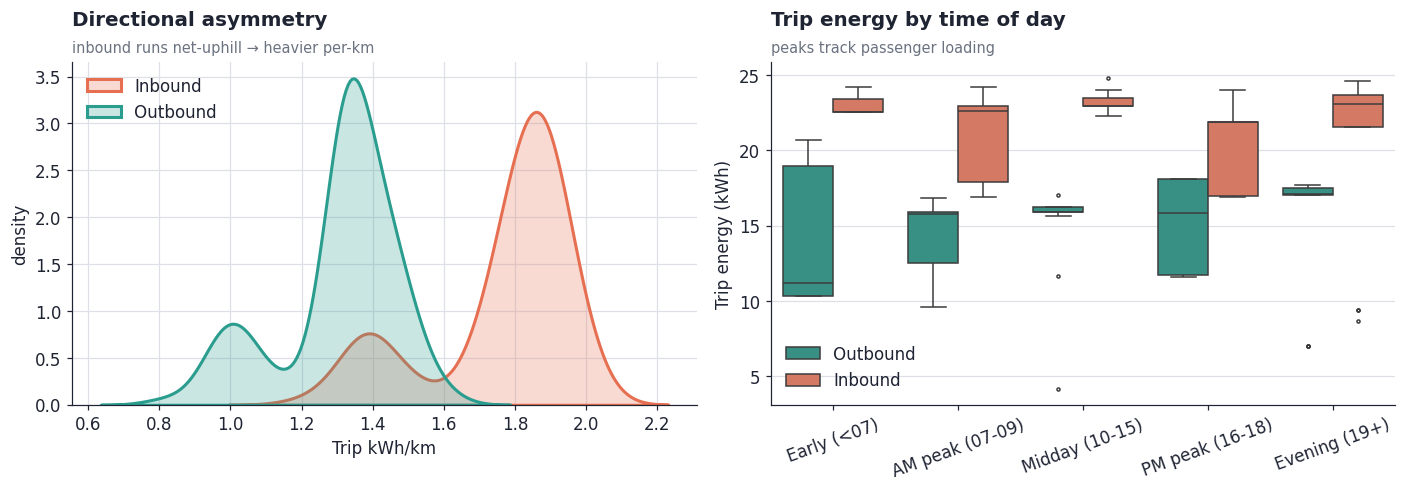

In [347]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for dlab, g in trips.groupby("dir_label"):
    sns.kdeplot(g.net_battery_kWh_per_km, ax=ax, fill=True, alpha=.25,
                color=DIRCOLORS[0 if dlab=="Outbound" else 1], label=dlab, lw=2)
ax.set_xlabel("Trip kWh/km"); ax.set_ylabel("density")
ax.legend(title="")
titled(ax, "Directional asymmetry", "inbound runs net-uphill → heavier per-km")

ax = axes[1]
sns.boxplot(data=trips, x="period", y="net_battery_energy_kWh", hue="dir_label",
            palette=[OUT, IN], ax=ax, fliersize=2, linewidth=1)
ax.set_xlabel(""); ax.set_ylabel("Trip energy (kWh)")
ax.tick_params(axis="x", rotation=20); ax.legend(title="")
titled(ax, "Trip energy by time of day", "peaks track passenger loading")
plt.tight_layout(); plt.show()

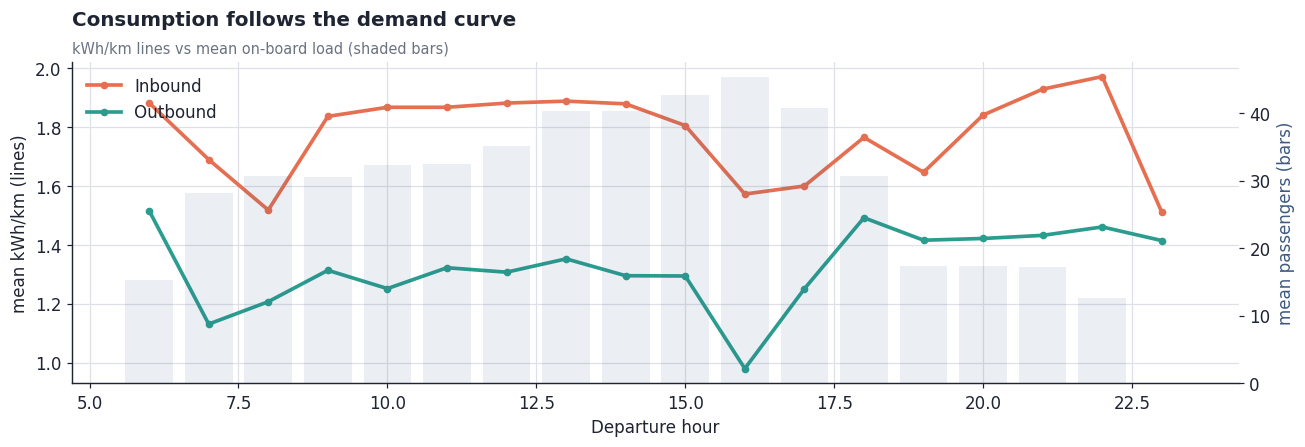

In [348]:
# Time-of-day consumption profile (mean kWh/km by departure hour, per direction)
prof = (trips.groupby(["dep_hour","dir_label"])
        .agg(kwh_km=("net_battery_kWh_per_km","mean"), pax=("pax_mean","mean")).reset_index())
fig, ax = plt.subplots(figsize=(12, 4.2))
ax2 = ax.twinx(); ax2.grid(False)
for dlab, g in prof.groupby("dir_label"):
    c = DIRCOLORS[0 if dlab=="Outbound" else 1]
    ax.plot(g.dep_hour, g.kwh_km, color=c, lw=2.4, marker="o", ms=4, label=dlab)
pax_all = trips.groupby("dep_hour")["pax_mean"].mean()
ax2.bar(pax_all.index, pax_all.values, color=ACC, alpha=.10, width=.8, zorder=0)
ax2.set_ylabel("mean passengers (bars)", color=ACC)
ax.set_xlabel("Departure hour"); ax.set_ylabel("mean kWh/km (lines)")
ax.legend(loc="upper left")
titled(ax, "Consumption follows the demand curve",
       "kWh/km lines vs mean on-board load (shaded bars)")
plt.tight_layout(); plt.show()

## 5 · Duty-level energy & state-of-charge

A **duty** is a full vehicle assignment for the day. This is the operationally decisive
level: it determines whether a vehicle completes its schedule on one charge and how much
reserve is left — directly feeding charging-infrastructure placement. The SoC trajectory
plot is the headline.

In [349]:
duties = (df.groupby("duty_id")
    .agg(service=("service_id","first"),
         trips=("duty_trip_index","nunique"),
         segs=("segment","count"), dist_km=("dist_km","sum"),
         net_battery_energy_kWh=("net_battery_energy_kWh","sum"),
         start=("trip_start_time","min"),
         pax_mean=("passengers","mean"),
         soc_end=("SoC_end_%","last"))
    .reset_index())
# min SoC actually reached anywhere in the duty (continuous within-duty SoC)
minsoc = (df.sort_values(["duty_id","duty_trip_index","segment"])
            .groupby("duty_id")["SoC_end_%"].min())
duties["soc_min"] = duties.duty_id.map(minsoc).values
duties["energy_per_km"] = duties.net_battery_energy_kWh / duties.dist_km
duties = duties.sort_values("net_battery_energy_kWh", ascending=False).reset_index(drop=True)
print(f"{len(duties)} duties | mean {duties.net_battery_energy_kWh.mean():.0f} kWh "
      f"({duties.net_battery_energy_kWh.mean()/BATTERY_KWH*100:.0f}% of pack) | "
      f"lowest end-SoC {duties.soc_min.min():.1f}%")
duties.head(8).round(2)

16 duties | mean 237 kWh (58% of pack) | lowest end-SoC 6.1%


,duty_id,service,trips,segs,dist_km,net_battery_energy_kWh,start,pax_mean,soc_end,soc_min,energy_per_km
0,228:5695_7778208_42080203,228,21,750,243.07,384.84,06:30:00,27.52,6.13,6.13,1.58
1,228:5695_7778208_42080205,228,20,729,236.05,368.80,06:50:00,27.98,10.06,10.06,1.56
2,228:5695_7778208_42080207,228,19,720,234.64,366.30,06:55:00,28.84,10.65,10.65,1.56
3,228:5695_7778208_42080206,228,20,724,236.69,365.22,06:40:00,28.22,10.91,10.91,1.54
4,228:5695_7778208_42080212,228,18,659,213.55,334.08,08:25:00,27.90,18.52,18.52,1.56
5,228:5695_7778208_42080211,228,14,511,166.97,259.00,08:00:00,29.06,36.83,36.83,1.55
6,228:5695_7778208_42080210,228,13,494,161.97,249.40,07:40:00,34.93,39.18,39.18,1.54
7,228:5695_7778208_42080209,228,13,502,165.56,245.87,07:05:00,34.64,40.01,40.01,1.49


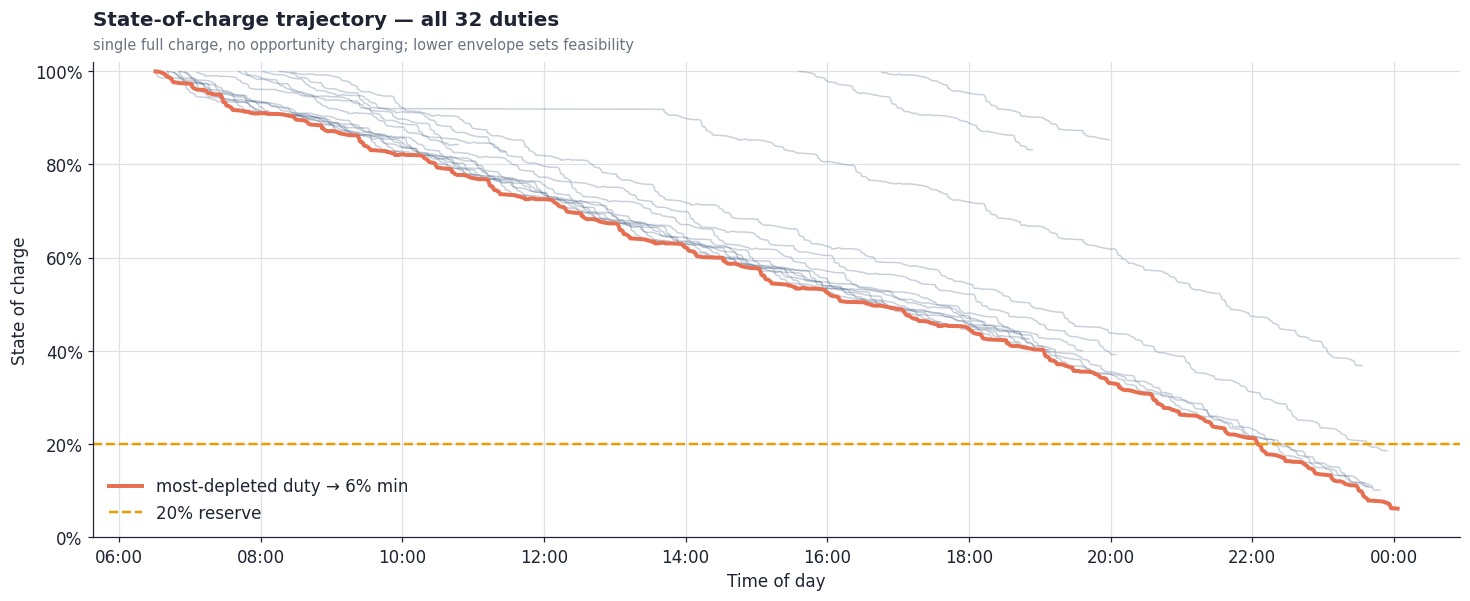

In [350]:
# Headline: SoC trajectory across the day for every duty
RESERVE = 20  # % operational reserve line
fig, ax = plt.subplots(figsize=(13.5, 5.6))
order = df.sort_values(["duty_id","duty_trip_index","segment"])
for did, g in order.groupby("duty_id"):
    ax.plot(g.seg_arr_dt, g["SoC_end_%"], color=ACC, alpha=.28, lw=1)
# highlight the single most-depleted duty
worst = duties.loc[duties.soc_min.idxmin()]
gw = order[order.duty_id == worst.duty_id]
ax.plot(gw.seg_arr_dt, gw["SoC_end_%"], color=IN, lw=2.6,
        label=f"most-depleted duty → {worst.soc_min:.0f}% min")
ax.axhline(RESERVE, color=ACC2, ls="--", lw=1.6, label=f"{RESERVE}% reserve")
ax.set_ylim(0, 102); ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Time of day"); ax.set_ylabel("State of charge")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="lower left")
titled(ax, "State-of-charge trajectory — all 32 duties",
       "single full charge, no opportunity charging; lower envelope sets feasibility")
plt.tight_layout(); plt.show()

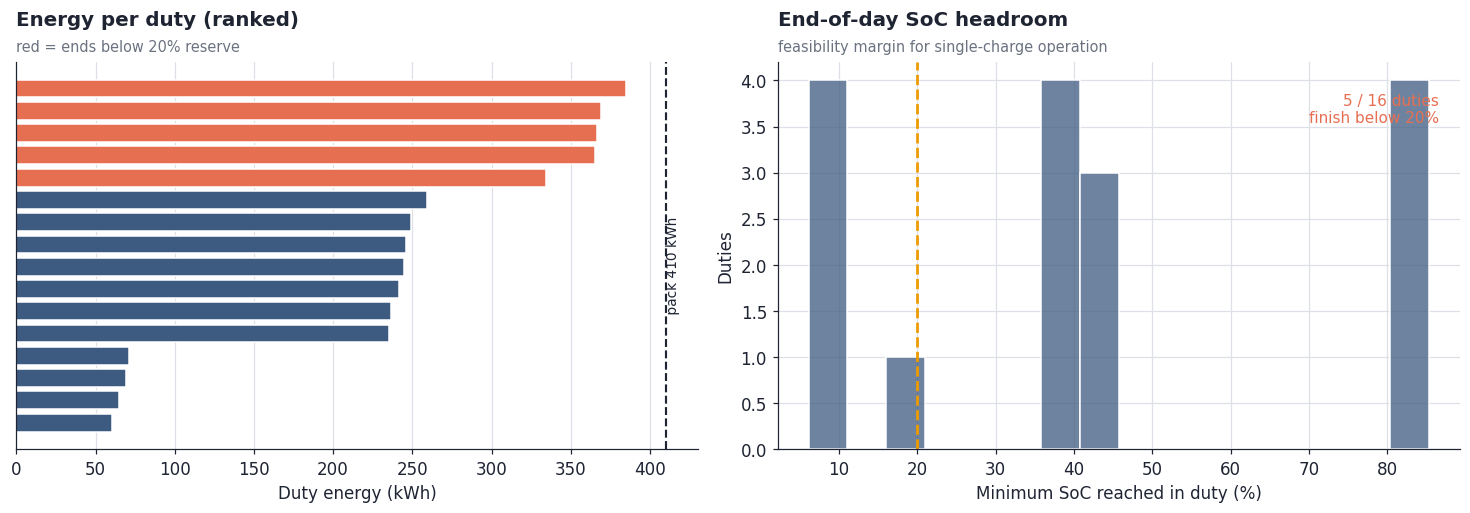

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
colors = [IN if v < RESERVE else ACC for v in duties.soc_min]
ax.barh(range(len(duties)), duties.net_battery_energy_kWh, color=colors, edgecolor="white")
ax.invert_yaxis(); ax.set_yticks([])
ax.axvline(BATTERY_KWH, color=INK, ls="--", lw=1.4)
ax.text(BATTERY_KWH, len(duties)*.5, f" pack {BATTERY_KWH:.0f} kWh",
        rotation=90, va="center", fontsize=9, color=INK)
ax.set_xlabel("Duty energy (kWh)")
titled(ax, "Energy per duty (ranked)",
       "red = ends below 20% reserve")

ax = axes[1]
sns.histplot(duties.soc_min, bins=16, color=ACC, edgecolor="white", ax=ax)
ax.axvline(RESERVE, color=ACC2, ls="--", lw=1.8)
n_risk = (duties.soc_min < RESERVE).sum()
ax.text(.97, .92, f"{n_risk} / {len(duties)} duties\nfinish below {RESERVE}%",
        transform=ax.transAxes, ha="right", va="top", color=IN, fontsize=10)
ax.set_xlabel("Minimum SoC reached in duty (%)"); ax.set_ylabel("Duties")
titled(ax, "End-of-day SoC headroom",
       "feasibility margin for single-charge operation")
plt.tight_layout(); plt.show()

## 6 · Passenger-loading analysis

The boarding profile shapes both crowding and the mass term in consumption. We look at
the load shape along the route, how demand moves through the day, and re-confirm the
energy cost of carrying passengers with grade and speed held in a narrow band.

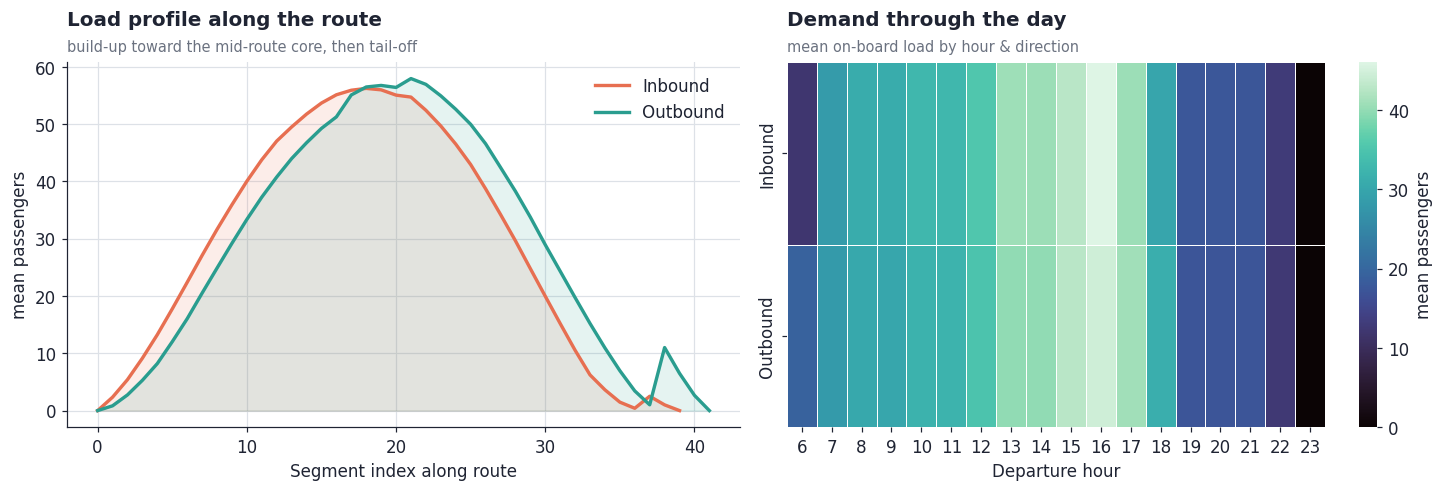

In [352]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# load shape along the route by direction
ax = axes[0]
ls = df.groupby(["segment","dir_label"])["passengers"].mean().reset_index()
for dlab, g in ls.groupby("dir_label"):
    c = DIRCOLORS[0 if dlab=="Outbound" else 1]
    ax.plot(g.segment, g.passengers, color=c, lw=2.2, label=dlab)
    ax.fill_between(g.segment, g.passengers, color=c, alpha=.12)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("mean passengers")
ax.legend(title="")
titled(ax, "Load profile along the route",
       "build-up toward the mid-route core, then tail-off")

# demand through the day x direction
ax = axes[1]
hd = df.pivot_table(index="dir_label", columns="dep_hour",
                    values="passengers", aggfunc="mean")
sns.heatmap(hd, cmap=SEQ, linewidths=.4, linecolor="white",
            cbar_kws={"label": "mean passengers"}, ax=ax)
ax.set_xlabel("Departure hour"); ax.set_ylabel("")
titled(ax, "Demand through the day", "mean on-board load by hour & direction")
plt.tight_layout(); plt.show()

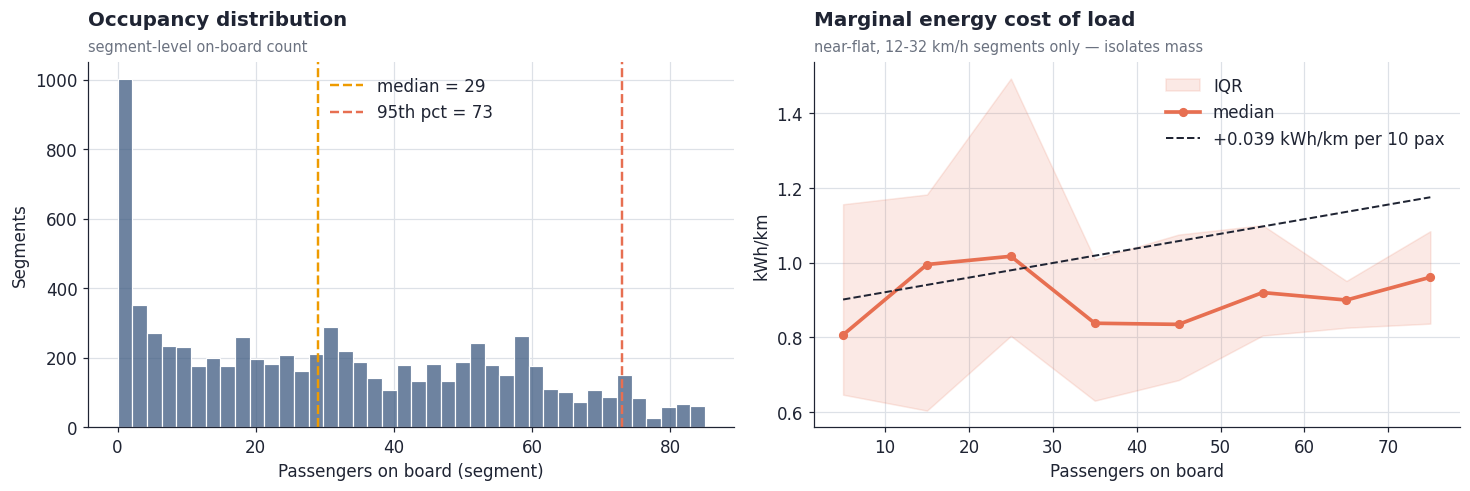

In [353]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# occupancy distribution
ax = axes[0]
sns.histplot(df.passengers, bins=40, color=ACC, edgecolor="white", ax=ax)
for q, lab in [(.5,"median"), (.95,"95th pct")]:
    v = df.passengers.quantile(q)
    ax.axvline(v, color=ACC2 if q==.5 else IN, lw=1.6, ls="--",
               label=f"{lab} = {v:.0f}")
ax.set_xlabel("Passengers on board (segment)"); ax.set_ylabel("Segments")
ax.legend()
titled(ax, "Occupancy distribution", "segment-level on-board count")

# energy cost of load, grade- & speed-controlled, with bootstrap-free IQR band
ax = axes[1]
flat = df[(df["grade_%"].abs() < 0.5) & df.speed_kmh.between(12, 32)].copy()
flat["pax_bin"] = pd.cut(flat.passengers, np.arange(0, 90, 10))
agg = flat.groupby("pax_bin", observed=True)["net_battery_kWh_per_km"].agg(
        median="median", q1=lambda s: s.quantile(.25),
        q3=lambda s: s.quantile(.75), n="count")
xm = [iv.mid for iv in agg.index]
ax.fill_between(xm, agg.q1, agg.q3, color=IN, alpha=.15, label="IQR")
ax.plot(xm, agg["median"], color=IN, lw=2.4, marker="o", ms=5, label="median")
# fit a simple slope for the headline number
sl, ic = np.polyfit(flat.passengers, flat.net_battery_kWh_per_km, 1)
ax.plot(xm, ic + sl*np.array(xm), color=INK, lw=1.3, ls="--",
        label=f"+{sl*10:.3f} kWh/km per 10 pax")
ax.set_xlabel("Passengers on board"); ax.set_ylabel("kWh/km")
ax.legend()
titled(ax, "Marginal energy cost of load",
       "near-flat, 12-32 km/h segments only — isolates mass")
plt.tight_layout(); plt.show()

## 7 · Synthesis

In [354]:
flat_all = df[(df["grade_%"].abs() < 0.5) & df.speed_kmh.between(12, 32)]
pax_slope = np.polyfit(flat_all.passengers, flat_all.net_battery_kWh_per_km, 1)[0]

summary = pd.Series({
    "Fleet mean consumption":     f"{df.net_battery_energy_kWh.sum()/df.dist_km.sum():.2f} kWh/km",
    "Implied pack capacity":      f"{BATTERY_KWH:.0f} kWh",
    "Mean energy per duty":       f"{duties.net_battery_energy_kWh.mean():.0f} kWh "
                                  f"({duties.net_battery_energy_kWh.mean()/BATTERY_KWH*100:.0f}% of pack)",
    "Heaviest duty":              f"{duties.net_battery_energy_kWh.max():.0f} kWh "
                                  f"({duties.net_battery_energy_kWh.max()/BATTERY_KWH*100:.0f}% of pack)",
    "Lowest SoC reached":         f"{duties.soc_min.min():.1f}%",
    "Duties below 20% reserve":   f"{(duties.soc_min<20).sum()} of {len(duties)}",
    "Regenerating segments":      f"{df.is_regen.mean()*100:.1f}%",
    "Marginal load cost":         f"+{pax_slope*10:.3f} kWh/km per 10 passengers",
    "Inbound vs outbound kWh/km": f"{trips[trips.direction==1].net_battery_kWh_per_km.mean():.2f}"
                                  f" vs {trips[trips.direction==0].net_battery_kWh_per_km.mean():.2f}",
}, name="")
print("ROUTE 208 — KEY FIGURES")
print("=" * 52)
print(summary.to_string())

ROUTE 208 — KEY FIGURES
Fleet mean consumption                            1.54 kWh/km
Implied pack capacity                                 410 kWh
Mean energy per duty                    237 kWh (58% of pack)
Heaviest duty                           385 kWh (94% of pack)
Lowest SoC reached                                       6.1%
Duties below 20% reserve                              5 of 16
Regenerating segments                                   13.7%
Marginal load cost            +0.039 kWh/km per 10 passengers
Inbound vs outbound kWh/km                       1.77 vs 1.31


**Takeaways**

- **Grade dominates** the per-segment energy signal; **in-motion speed** contributes a
  U-shaped term (crawl + aero) and **passenger mass** a smaller, near-linear term that
  the grade-controlled view isolates cleanly.
- **Direction matters**: the net-uphill direction carries a persistently higher kWh/km,
  so directional asymmetry should not be averaged away in placement modelling.
- **Duty SoC headroom** is the operational crux — the lower envelope of the trajectory
  plot, not the mean, decides single-charge feasibility and where opportunity charging
  would buy the most margin.

*Caveats:* one simulated winter day, single route; the least-squares decomposition is
descriptive bookkeeping (collinear terms), not a causal model; the load slope is
estimated on a deliberately narrow grade/speed band to suppress confounding.

## 8 · Multi-date comparison

Compare energy consumption across simulated days. **To change which days are compared,
edit the `COMPARE` dict below** — drop a line for a 2-day comparison, add lines for more.
Everything downstream (tables, colours, charts) adapts to whatever is in the dict.

Two things to keep in mind when reading this section:

- **2025-01-06 and 2025-04-14 share the identical schedule** (services 226 + 242, the
  same 412 trips), so that pair is a *controlled* contrast — the only thing that moves is
  the weather/HVAC input. **2025-07-12 runs a different service pattern** (services
  124 / 240 / 122, 519 trips), so it differs in schedule *and* weather; its totals are
  not directly comparable to the other two.
- To compare like-with-like despite that, the **controlled-segment** chart below matches
  grade, speed and passenger band before comparing, isolating the per-segment
  weather/HVAC term from schedule and trip-mix effects.

In [355]:
# EDIT HERE: choose the days to compare (any 2, 3, 4+). Comment a line out to drop it.
COMPARE = {
    "2025-01-06": "../data/processed/route_208_trips_2025_01_06.csv",
    "2025-04-14": "../data/processed/route_208_trips_2025_04_14.csv",
    "2025-07-09": "../data/processed/route_208_trips_2025_07_09.csv",
}

def load_day(path):
    d = normalize_energy_schema(pd.read_csv(path))
    d["dist_km"]   = d["length_m"] / 1000.0
    d["speed_kmh"] = d["length_m"] / d["run_time_s"] * 3.6
    d["is_regen"]  = d["net_battery_energy_kWh"] < 0
    d["dir_label"] = d["direction_id"].map({0: "Outbound", 1: "Inbound"})
    d["dep_hour"]  = pd.to_datetime(d["trip_start_time"], format="%H:%M:%S").dt.hour
    return d

combo = pd.concat([load_day(p).assign(date=lbl) for lbl, p in COMPARE.items()],
                  ignore_index=True)
DATES = sorted(COMPARE)                                   # chronological order
COMBO_BREAKDOWN = has_breakdown(combo)                    # all days carry breakdown?
_pal  = sns.color_palette("Set2", n_colors=max(len(DATES), 3))
DCOLOR = {dt: _pal[i] for i, dt in enumerate(DATES)}      # stable colour per day, any N

print(f"Loaded {len(DATES)} day(s): {', '.join(DATES)}  |  {len(combo):,} segments total")
print("energy breakdown:", "available" if COMBO_BREAKDOWN else "legacy schema (no aux split)")

Loaded 3 day(s): 2025-01-06, 2025-04-14, 2025-07-09  |  22,683 segments total
energy breakdown: available


In [356]:
# Side-by-side summary - surfaces schedule differences and headline consumption
def day_summary(d):
    return pd.Series({
        "services":    ", ".join(map(str, sorted(d.service_id.unique()))),
        "trips":       d.trip_id.nunique(),
        "duties":      d.duty_id.nunique(),
        "total_km":    round(d.dist_km.sum(), 0),
        "total_kWh":   round(d.net_battery_energy_kWh.sum(), 0),
        "mean_kWh/km": round(d.net_battery_energy_kWh.sum() / d.dist_km.sum(), 3),
        "regen_%":     round(d.is_regen.mean() * 100, 1),
        "pax_mean":    round(d.passengers.mean(), 1),
    })
summary = pd.DataFrame({dt: day_summary(combo[combo.date == dt]) for dt in DATES}).T
summary

,services,trips,duties,total_km,total_kWh,mean_kWh/km,regen_%,pax_mean
2025-01-06,228,206,16,2463.0,4072.0,1.653,11.8,31.1
2025-04-14,228,206,16,2463.0,3797.0,1.541,13.7,31.1
2025-07-09,234,206,16,2463.0,3797.0,1.541,13.7,31.1


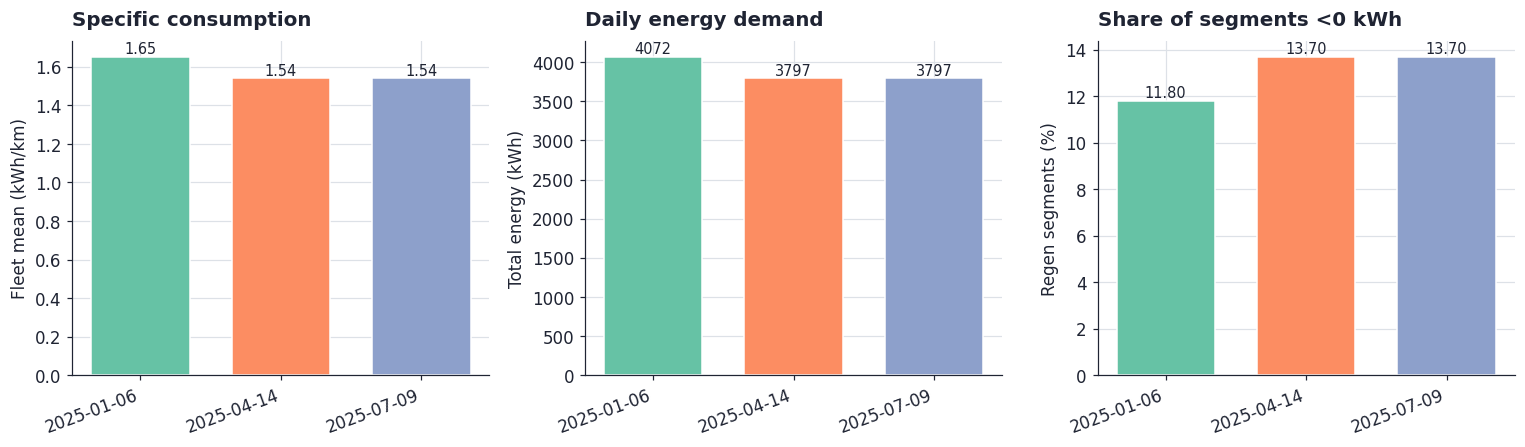

In [357]:
# Fleet-level headline bars
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
metrics = [("mean_kWh/km", "Fleet mean (kWh/km)", "Specific consumption"),
           ("total_kWh",   "Total energy (kWh)",  "Daily energy demand"),
           ("regen_%",     "Regen segments (%)",  "Share of segments <0 kWh")]
for ax, (col, ylab, title) in zip(axes, metrics):
    vals = summary[col].astype(float)
    bars = ax.bar(range(len(DATES)), [vals[d] for d in DATES],
                  color=[DCOLOR[d] for d in DATES], edgecolor="white", width=.7)
    ax.set_xticks(range(len(DATES))); ax.set_xticklabels(DATES, rotation=20, ha="right")
    ax.set_ylabel(ylab)
    for b, d in zip(bars, DATES):
        lab = f"{vals[d]:.0f}" if col == "total_kWh" else f"{vals[d]:.2f}"
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), lab,
                ha="center", va="bottom", fontsize=9.5)
    titled(ax, title)
plt.tight_layout(); plt.show()

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_36344\875274308.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(DATES, rotation=20, ha="right")


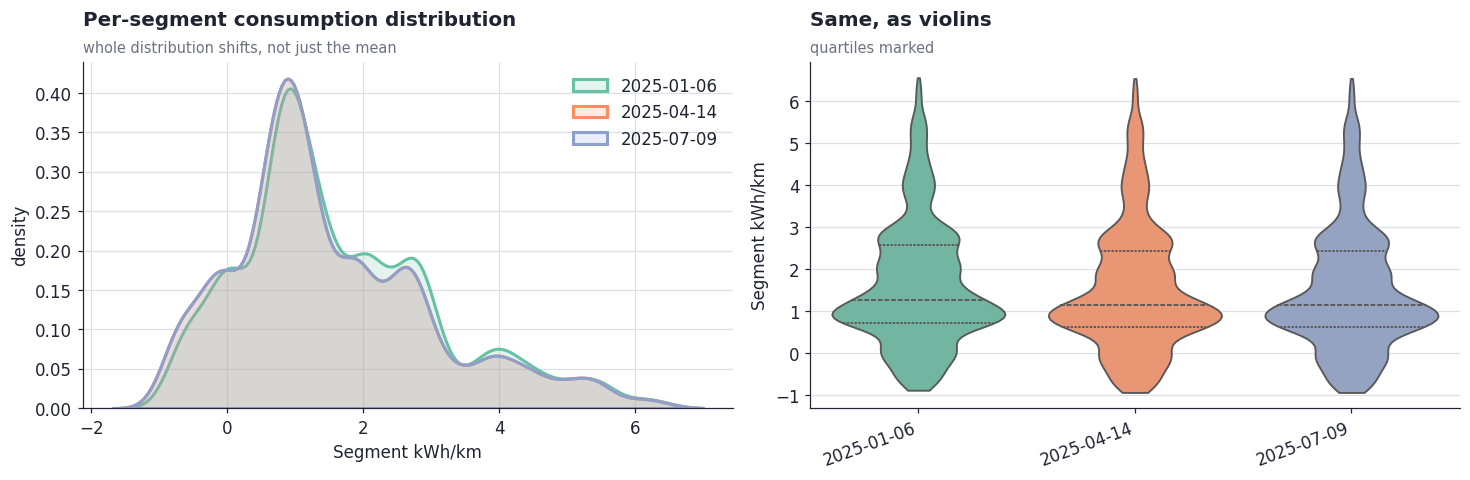

In [358]:
# Distribution shift of per-segment specific consumption
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax = axes[0]
for dt in DATES:
    s = combo.loc[combo.date == dt, "net_battery_kWh_per_km"]
    sns.kdeplot(s, ax=ax, color=DCOLOR[dt], fill=True, alpha=.18, lw=2,
                clip=(-2, 7), label=dt)
ax.set_xlabel("Segment kWh/km"); ax.set_ylabel("density"); ax.legend(title="")
titled(ax, "Per-segment consumption distribution",
       "whole distribution shifts, not just the mean")

ax = axes[1]
sns.violinplot(data=combo[combo.net_battery_kWh_per_km.between(-2, 7)], x="date", y="net_battery_kWh_per_km",
               order=DATES, hue="date", hue_order=DATES, palette=DCOLOR,
               legend=False, cut=0, inner="quartile", ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Segment kWh/km")
ax.set_xticklabels(DATES, rotation=20, ha="right")
titled(ax, "Same, as violins", "quartiles marked")
plt.tight_layout(); plt.show()

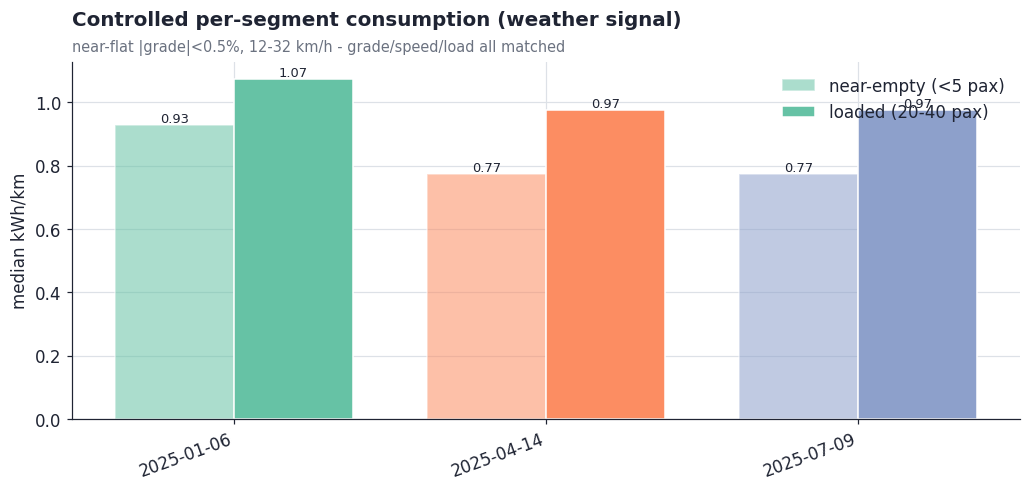

In [359]:
# CONTROLLED comparison - match grade, speed & load before comparing.
# This is the apples-to-apples weather/HVAC signal, free of schedule/trip-mix.
ctrl = combo[(combo["grade_%"].abs() < 0.5) & combo.speed_kmh.between(12, 32)]
base = ctrl[ctrl.passengers < 5].groupby("date")["net_battery_kWh_per_km"].median()
load = ctrl[ctrl.passengers.between(20, 40)].groupby("date")["net_battery_kWh_per_km"].median()

fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(DATES)); w = 0.38
ax.bar(x - w/2, [base[d] for d in DATES], w, color=[DCOLOR[d] for d in DATES],
       alpha=.55, edgecolor="white", label="near-empty (<5 pax)")
ax.bar(x + w/2, [load[d] for d in DATES], w, color=[DCOLOR[d] for d in DATES],
       edgecolor="white", label="loaded (20-40 pax)")
for xi, d in zip(x, DATES):
    ax.text(xi - w/2, base[d], f"{base[d]:.2f}", ha="center", va="bottom", fontsize=8.5)
    ax.text(xi + w/2, load[d], f"{load[d]:.2f}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(DATES, rotation=20, ha="right")
ax.set_ylabel("median kWh/km"); ax.legend(title="")
titled(ax, "Controlled per-segment consumption (weather signal)",
       "near-flat |grade|<0.5%, 12-32 km/h - grade/speed/load all matched")
plt.tight_layout(); plt.show()

> **Flag for investigation.** On these matched segments the **2025-07-12** simulation
> draws markedly *more* energy than the January and April days (visible above), and the
> gap survives controlling for grade, speed and passenger load — so it is a genuine
> per-segment effect, not the different July schedule. For the Irish climate, where
> heating dominates and the cooling side is expected to be near-negligible, a summer day
> exceeding mid-winter is counterintuitive.
>
> With the new explicit breakdown we can now test this directly rather than infer it: if
> the excess sits in **`aux_energy_kWh`**, it points squarely at the HVAC/weather term
> (`weather_loading.py`) rather than traction. The chart below splits net consumption into
> gross / aux / regen per day. *(Skipped on legacy files without the breakdown.)*

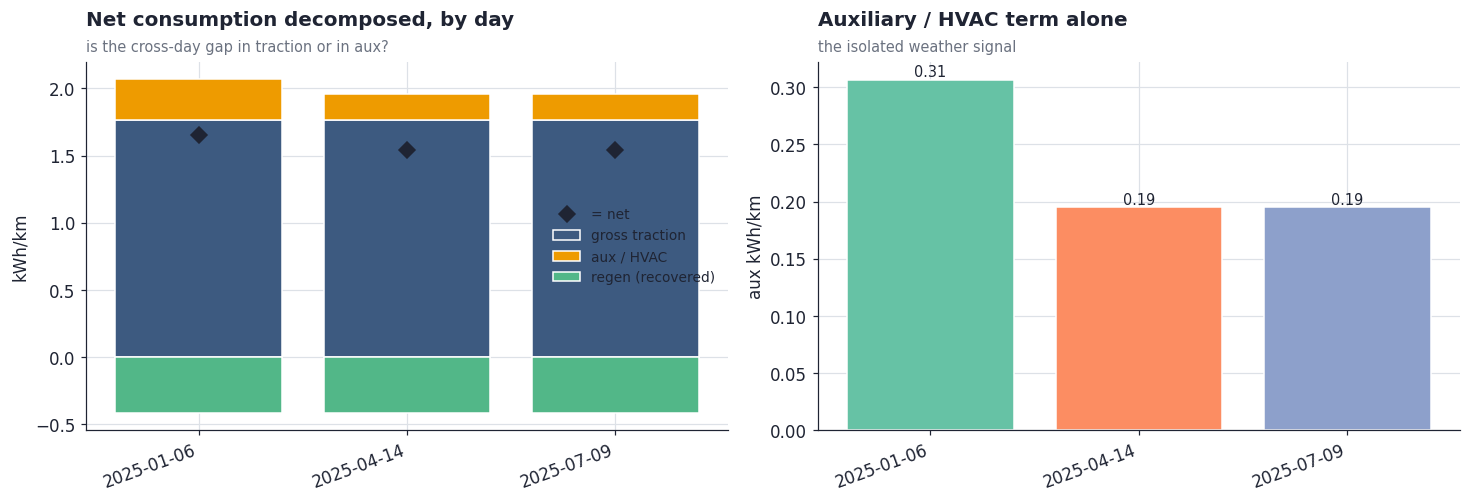

Auxiliary share of net battery energy, by day:
  2025-01-06: aux = 19% of net
  2025-04-14: aux = 13% of net  (-36% aux/km vs 2025-01-06)
  2025-07-09: aux = 13% of net  (-36% aux/km vs 2025-01-06)


In [360]:
# Decompose net kWh/km into gross / aux / regen per day - locates the anomaly
if not COMBO_BREAKDOWN:
    print("Breakdown columns absent for one or more days - skipping the aux diagnosis. "
          "Regenerate the CSVs with the new model to enable it.")
else:
    parts = []
    for dt in DATES:
        s = combo[combo.date == dt]; km = s.dist_km.sum()
        parts.append({"date": dt,
                      "gross/km": s.gross_consumed_kWh.sum() / km,
                      "aux/km":   s.aux_energy_kWh.sum() / km,
                      "regen/km": s.regen_recovered_kWh.sum() / km,
                      "net/km":   s.net_battery_energy_kWh.sum() / km})
    P = pd.DataFrame(parts).set_index("date")

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.7))

    # stacked composition per day (gross + aux, regen shown as recovery)
    ax = axes[0]; x = np.arange(len(DATES))
    ax.bar(x, P["gross/km"], color=ACC, edgecolor="white", label="gross traction")
    ax.bar(x, P["aux/km"], bottom=P["gross/km"], color=ACC2, edgecolor="white",
           label="aux / HVAC")
    ax.bar(x, -P["regen/km"], color=REGEN, edgecolor="white", label="regen (recovered)")
    ax.plot(x, P["net/km"], "D", color=INK, ms=7, label="= net")
    ax.set_xticks(x); ax.set_xticklabels(DATES, rotation=20, ha="right")
    ax.set_ylabel("kWh/km"); ax.legend(title="", fontsize=9)
    titled(ax, "Net consumption decomposed, by day",
           "is the cross-day gap in traction or in aux?")

    # aux term alone - the weather/HVAC signal
    ax = axes[1]
    bars = ax.bar(x, P["aux/km"], color=[DCOLOR[d] for d in DATES], edgecolor="white")
    for b, d in zip(bars, DATES):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{P['aux/km'][d]:.2f}",
                ha="center", va="bottom", fontsize=9.5)
    ax.set_xticks(x); ax.set_xticklabels(DATES, rotation=20, ha="right")
    ax.set_ylabel("aux kWh/km")
    titled(ax, "Auxiliary / HVAC term alone", "the isolated weather signal")
    plt.tight_layout(); plt.show()

    ref = DATES[0]
    print("Auxiliary share of net battery energy, by day:")
    for dt in DATES:
        s = combo[combo.date == dt]
        share = s.aux_energy_kWh.sum() / s.net_battery_energy_kWh.sum() * 100
        d_aux = (P["aux/km"][dt] / P["aux/km"][ref] - 1) * 100 if dt != ref else 0
        tag = "" if dt == ref else f"  ({d_aux:+.0f}% aux/km vs {ref})"
        print(f"  {dt}: aux = {share:.0f}% of net{tag}")

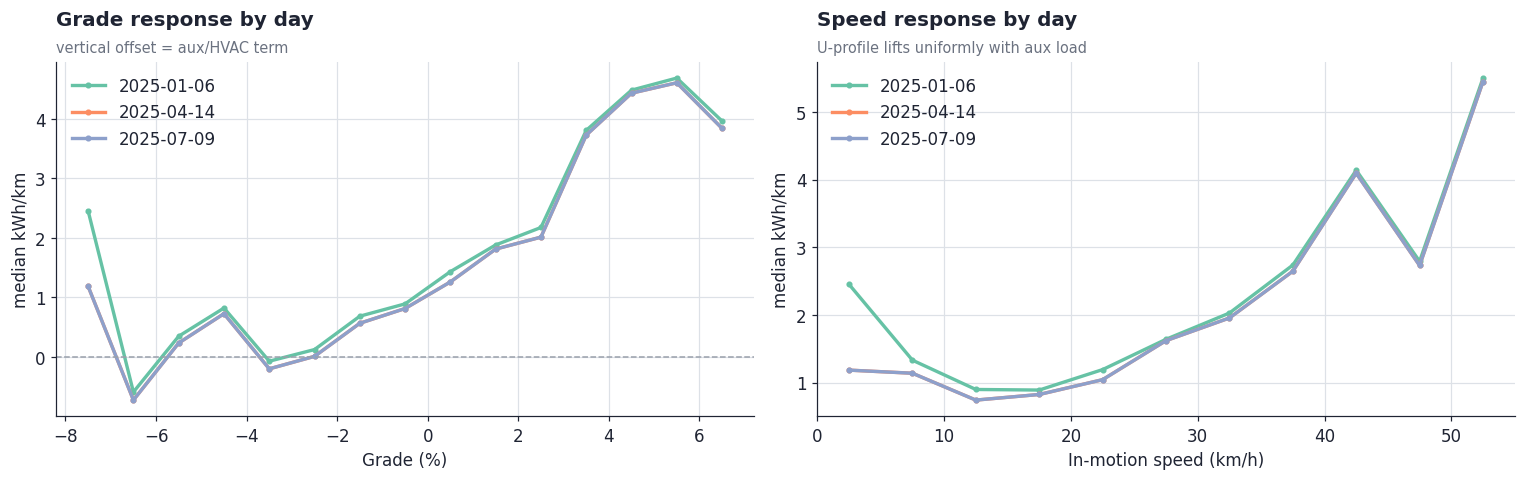

In [361]:
# Driver curves overlaid by day - does the whole grade response shift?
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

g = combo[combo.net_battery_kWh_per_km.between(-4, 8)].copy()
g["gb"] = pd.cut(g["grade_%"], np.arange(-9, 9, 1))
ax = axes[0]
for dt in DATES:
    s = (g[g.date == dt].groupby("gb", observed=True)["net_battery_kWh_per_km"].median())
    ax.plot([iv.mid for iv in s.index], s.values, color=DCOLOR[dt], lw=2.2,
            marker="o", ms=3, label=dt)
ax.axhline(0, color="#9aa0ab", lw=1, ls="--")
ax.set_xlabel("Grade (%)"); ax.set_ylabel("median kWh/km"); ax.legend(title="")
titled(ax, "Grade response by day", "vertical offset = aux/HVAC term")

g["sb"] = pd.cut(g["speed_kmh"], np.arange(0, 60, 5))
ax = axes[1]
for dt in DATES:
    s = (g[g.date == dt].groupby("sb", observed=True)["net_battery_kWh_per_km"].median())
    ax.plot([iv.mid for iv in s.index], s.values, color=DCOLOR[dt], lw=2.2,
            marker="o", ms=3, label=dt)
ax.set_xlabel("In-motion speed (km/h)"); ax.set_ylabel("median kWh/km"); ax.legend(title="")
titled(ax, "Speed response by day", "U-profile lifts uniformly with aux load")
plt.tight_layout(); plt.show()

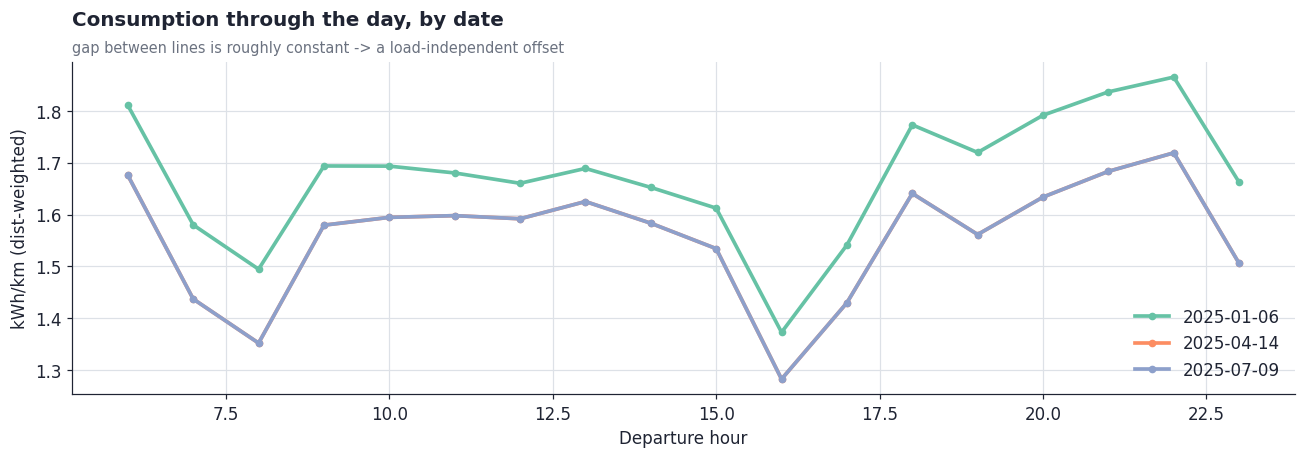

In [362]:
# Time-of-day consumption profile, one line per day (distance-weighted)
tod = (combo.groupby(["date", "dep_hour"])
       .agg(e=("net_battery_energy_kWh", "sum"), d=("dist_km", "sum")).reset_index())
tod["kWh_km"] = tod.e / tod.d
fig, ax = plt.subplots(figsize=(12, 4.3))
for dt in DATES:
    s = tod[tod.date == dt]
    ax.plot(s.dep_hour, s.kWh_km, color=DCOLOR[dt], lw=2.4, marker="o", ms=4, label=dt)
ax.set_xlabel("Departure hour"); ax.set_ylabel("kWh/km (dist-weighted)")
ax.legend(title="")
titled(ax, "Consumption through the day, by date",
       "gap between lines is roughly constant -> a load-independent offset")
plt.tight_layout(); plt.show()

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_36344\3548148125.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(DATES, rotation=20, ha="right")
C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_36344\3548148125.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(DATES, rotation=20, ha="right")


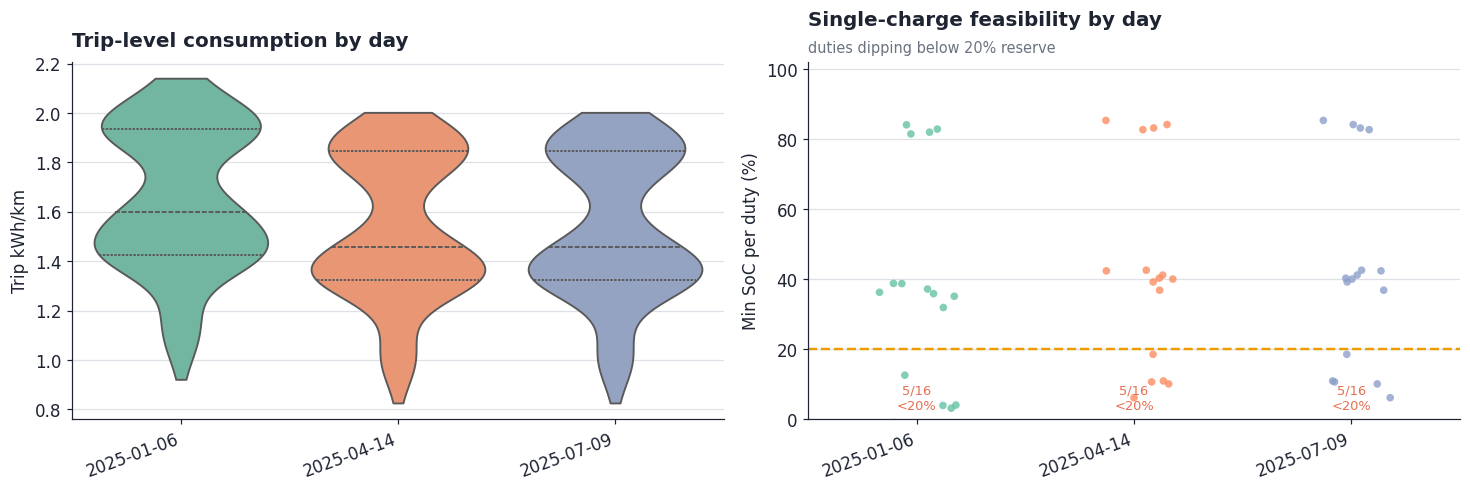

In [363]:
# Trip-level energy intensity + duty feasibility, by day
ct = (combo.groupby(["date", "trip_id"])
      .agg(e=("net_battery_energy_kWh", "sum"), dist=("dist_km", "sum")).reset_index())
ct["net_battery_kWh_per_km"] = ct.e / ct.dist
dmin = (combo.groupby(["date", "duty_id"])["SoC_end_%"].min()
        .reset_index(name="soc_min"))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axes[0]
sns.violinplot(data=ct, x="date", y="net_battery_kWh_per_km", order=DATES, hue="date",
               hue_order=DATES, palette=DCOLOR, legend=False, cut=0,
               inner="quartile", ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Trip kWh/km")
ax.set_xticklabels(DATES, rotation=20, ha="right")
titled(ax, "Trip-level consumption by day")

ax = axes[1]
sns.stripplot(data=dmin, x="date", y="soc_min", order=DATES, hue="date",
              hue_order=DATES, palette=DCOLOR, legend=False, size=5, alpha=.8,
              jitter=.18, ax=ax)
ax.axhline(20, color=ACC2, ls="--", lw=1.6)
for i, dt in enumerate(DATES):
    n = (dmin[dmin.date == dt].soc_min < 20).sum()
    tot = (dmin.date == dt).sum()
    ax.text(i, 2, f"{n}/{tot}\n<20%", ha="center", va="bottom", fontsize=8.5, color=IN)
ax.set_ylim(0, 102); ax.set_xlabel(""); ax.set_ylabel("Min SoC per duty (%)")
ax.set_xticklabels(DATES, rotation=20, ha="right")
titled(ax, "Single-charge feasibility by day", "duties dipping below 20% reserve")
plt.tight_layout(); plt.show()

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_36344\752648796.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(DATES, rotation=20, ha="right")


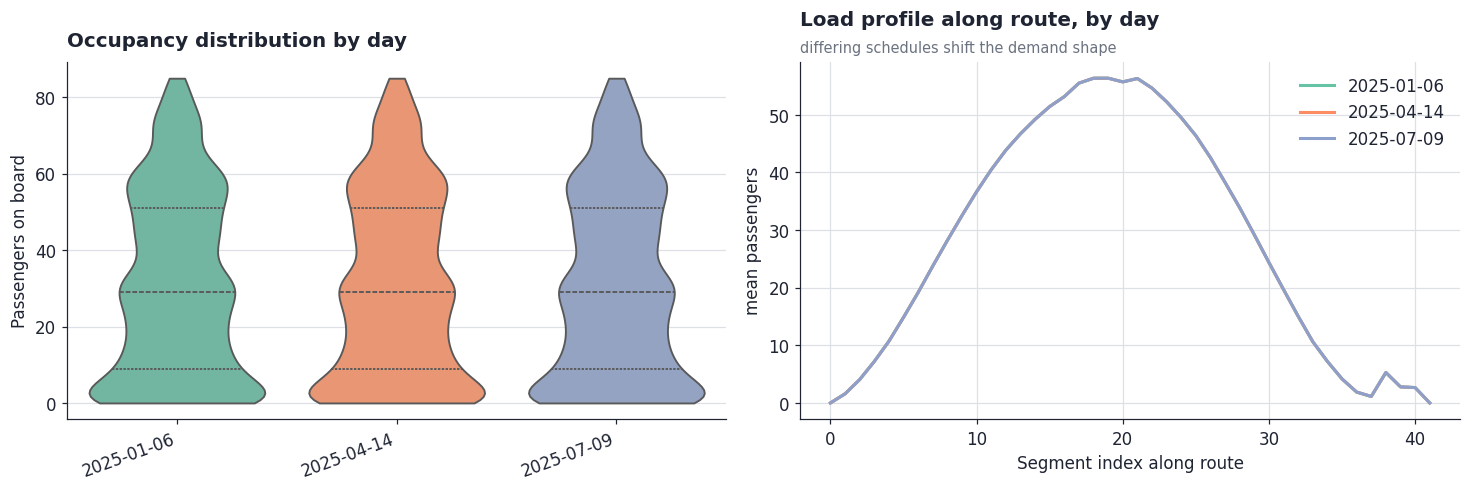

In [364]:
# Passenger-loading comparison: distribution + load shape along the route
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
sns.violinplot(data=combo, x="date", y="passengers", order=DATES, hue="date",
               hue_order=DATES, palette=DCOLOR, legend=False, cut=0,
               inner="quartile", ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Passengers on board")
ax.set_xticklabels(DATES, rotation=20, ha="right")
titled(ax, "Occupancy distribution by day")

ax = axes[1]
lp = combo.groupby(["date", "segment"])["passengers"].mean().reset_index()
for dt in DATES:
    s = lp[lp.date == dt]
    ax.plot(s.segment, s.passengers, color=DCOLOR[dt], lw=2, label=dt)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("mean passengers")
ax.legend(title="")
titled(ax, "Load profile along route, by day",
       "differing schedules shift the demand shape")
plt.tight_layout(); plt.show()

In [365]:
# Compact comparison readout
print("MULTI-DAY COMPARISON - KEY FIGURES")
print("=" * 60)
ref = DATES[0]
base_mk = combo[combo.date == ref].net_battery_energy_kWh.sum() / combo[combo.date == ref].dist_km.sum()
for dt in DATES:
    s = combo[combo.date == dt]
    mk = s.net_battery_energy_kWh.sum() / s.dist_km.sum()
    ck = ctrl[(ctrl.date == dt) & ctrl.passengers.between(20, 40)]["net_battery_kWh_per_km"].median()
    delta = "" if dt == ref else f"  ({(mk/base_mk-1)*100:+.1f}% vs {ref})"
    n_risk = (dmin[dmin.date == dt].soc_min < 20).sum()
    print(f"{dt} | fleet {mk:.3f} kWh/km{delta}")
    print(f"{'':10} | controlled (matched seg) {ck:.3f} kWh/km | {n_risk} duties <20% reserve")
print("=" * 60)
print("Note: 01-06 & 04-14 share the schedule (controlled weather contrast);")
print("07-12 uses a different service pattern, so compare it via the controlled rows.")

MULTI-DAY COMPARISON - KEY FIGURES
2025-01-06 | fleet 1.653 kWh/km
           | controlled (matched seg) 1.073 kWh/km | 5 duties <20% reserve
2025-04-14 | fleet 1.541 kWh/km  (-6.8% vs 2025-01-06)
           | controlled (matched seg) 0.974 kWh/km | 5 duties <20% reserve
2025-07-09 | fleet 1.541 kWh/km  (-6.8% vs 2025-01-06)
           | controlled (matched seg) 0.974 kWh/km | 5 duties <20% reserve
Note: 01-06 & 04-14 share the schedule (controlled weather contrast);
07-12 uses a different service pattern, so compare it via the controlled rows.
